In [ ]:
Name: Lukhi Laksh Nareshbhai
Enrollment Number: SR25MSAD016

In [1]:
import os

print("Datasets attached to this Kaggle Notebook:")
print(os.listdir("/kaggle/input"))

Datasets attached to this Kaggle Notebook:
['datasets']


In [2]:
import os

dataset_path = "/kaggle/input/datasets"

print("Files and folders:")
for root, dirs, files in os.walk(dataset_path):
    print("\nFolder:", root)
    for file in files:
        print("  ", file)

Files and folders:

Folder: /kaggle/input/datasets

Folder: /kaggle/input/datasets/harshitshankhdhar

Folder: /kaggle/input/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows
   imdb_top_1000.csv


In [3]:
import pandas as pd

file_path = "/kaggle/input/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows/imdb_top_1000.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Shape: (1000, 16)

Columns:
['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross']

First 5 rows:


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [4]:
print("Overview column:")
print(df["Overview"].head())

print("\nIMDb Rating:")
print(df["IMDB_Rating"].head())

Overview column:
0    Two imprisoned men bond over a number of years...
1    An organized crime dynasty's aging patriarch t...
2    When the menace known as the Joker wreaks havo...
3    The early life and career of Vito Corleone in ...
4    A jury holdout attempts to prevent a miscarria...
Name: Overview, dtype: object

IMDb Rating:
0    9.3
1    9.2
2    9.0
3    9.0
4    9.0
Name: IMDB_Rating, dtype: float64


In [5]:
import os
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Column names:
['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 

In [7]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64


In [8]:
data = df[["Overview", "IMDB_Rating"]].copy()

print("Selected columns:")
display(data.head())

print("Shape:", data.shape)

Selected columns:


,Overview,IMDB_Rating
0,Two imprisoned men bond over a number of years...,9.3
1,An organized crime dynasty's aging patriarch t...,9.2
2,When the menace known as the Joker wreaks havo...,9.0
3,The early life and career of Vito Corleone in ...,9.0
4,A jury holdout attempts to prevent a miscarria...,9.0


Shape: (1000, 2)


In [9]:
data = data.dropna(subset=["Overview", "IMDB_Rating"])

data["Overview"] = data["Overview"].astype(str)

print("Shape after removing missing values:", data.shape)

Shape after removing missing values: (1000, 2)


In [13]:
# Convert IMDb ratings to numeric
data["IMDB_Rating"] = pd.to_numeric(
    data["IMDB_Rating"],
    errors="coerce"
)

# Remove rows where rating is missing
data = data.dropna(
    subset=["IMDB_Rating", "Overview"]
)

# Create sentiment labels
data["sentiment"] = "neutral"

# Positive: rating >= 7
data.loc[
    data["IMDB_Rating"] >= 7,
    "sentiment"
] = "positive"

# Negative: rating <= 5
data.loc[
    data["IMDB_Rating"] <= 5,
    "sentiment"
] = "negative"

# Remove neutral ratings (between 5 and 7)
data = data[
    data["sentiment"].isin(["positive", "negative"])
].copy()

print("Sentiment distribution:")
print(data["sentiment"].value_counts())

print("\nFinal dataset shape:")
print(data.shape)

Sentiment distribution:
sentiment
positive    1000
Name: count, dtype: int64

Final dataset shape:
(1000, 3)


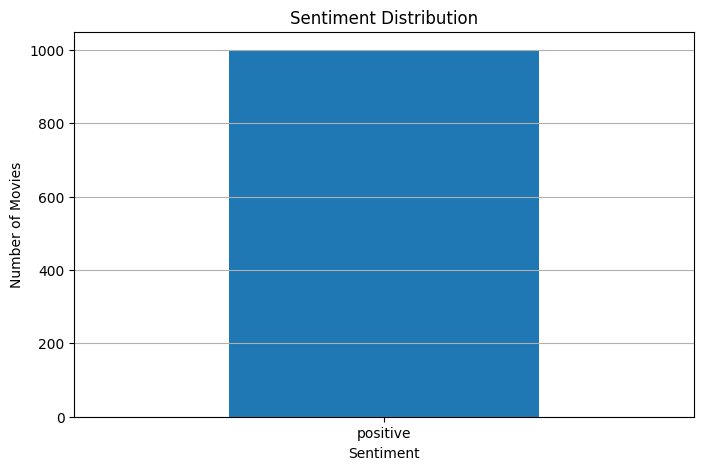

In [14]:
plt.figure(figsize=(8, 5))

data["sentiment"].value_counts().plot(
    kind="bar"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Movies")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

In [16]:
stemmer = PorterStemmer()

stop_words = set(ENGLISH_STOP_WORDS)

def preprocess_text(text):
    
    # 1. Convert to lowercase
    text = text.lower()
    
    # 2. Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    
    # 3. Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    # 4. Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )
    
    # 5. Remove numbers
    text = re.sub(r"\d+", " ", text)
    
    # Tokenization
    words = text.split()
    
    # 6. Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]
    
    # 7. Stemming
    words = [
        stemmer.stem(word)
        for word in words
    ]
    
    # 8. Remove extra whitespace
    text = " ".join(words)
    
    return text

In [17]:
data["clean_text"] = data["Overview"].apply(
    preprocess_text
)

print("Original text:")
print(data["Overview"].iloc[0])

print("\nCleaned text:")
print(data["clean_text"].iloc[0])

Original text:
Two imprisoned men bond over a number of years, finding solace and eventual redemption through acts of common decency.

Cleaned text:
imprison men bond number year find solac eventu redempt act common decenc


In [18]:
X = data["clean_text"]
y = data["sentiment"]

print("Number of samples:", len(X))
print("\nSentiment labels:")
print(y.value_counts())

Number of samples: 1000

Sentiment labels:
sentiment
positive    1000
Name: count, dtype: int64


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining percentage:",
      round(len(X_train) / len(X) * 100, 2), "%")

print("Testing percentage:",
      round(len(X_test) / len(X) * 100, 2), "%")

Training samples: 700
Testing samples: 300

Training percentage: 70.0 %
Testing percentage: 30.0 %


In [20]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF completed successfully!")

print("Training TF-IDF shape:",
      X_train_tfidf.shape)

print("Testing TF-IDF shape:",
      X_test_tfidf.shape)

TF-IDF completed successfully!
Training TF-IDF shape: (700, 5000)
Testing TF-IDF shape: (300, 5000)


In [22]:
# Check rating range
print("Minimum IMDb Rating:", data["IMDB_Rating"].min())
print("Maximum IMDb Rating:", data["IMDB_Rating"].max())
print("Median IMDb Rating:", data["IMDB_Rating"].median())

Minimum IMDb Rating: 7.6
Maximum IMDb Rating: 9.3
Median IMDb Rating: 7.9


In [23]:
# Calculate median rating
median_rating = data["IMDB_Rating"].median()

# Create sentiment labels based on median rating
data["sentiment"] = np.where(
    data["IMDB_Rating"] >= median_rating,
    "positive",
    "negative"
)

print("Median Rating:", median_rating)

print("\nSentiment Distribution:")
print(data["sentiment"].value_counts())

Median Rating: 7.9

Sentiment Distribution:
sentiment
positive    569
negative    431
Name: count, dtype: int64


In [24]:
print("Unique sentiment classes:")
print(data["sentiment"].unique())

print("\nNumber of classes:")
print(data["sentiment"].nunique())

Unique sentiment classes:
['positive' 'negative']

Number of classes:
2


In [25]:
data["clean_text"] = data["Overview"].apply(
    preprocess_text
)

print("Text preprocessing completed!")

display(
    data[["Overview", "clean_text", "sentiment"]].head()
)

Text preprocessing completed!


,Overview,clean_text,sentiment
0,Two imprisoned men bond over a number of years...,imprison men bond number year find solac event...,positive
1,An organized crime dynasty's aging patriarch t...,organ crime dynasti age patriarch transfer con...,positive
2,When the menace known as the Joker wreaks havo...,menac known joker wreak havoc chao peopl gotha...,positive
3,The early life and career of Vito Corleone in ...,earli life career vito corleon s new york citi...,positive
4,A jury holdout attempts to prevent a miscarria...,juri holdout attempt prevent miscarriag justic...,positive


In [26]:
X = data["clean_text"]
y = data["sentiment"]

print("Total samples:", len(X))

print("\nClass distribution:")
print(y.value_counts())

Total samples: 1000

Class distribution:
sentiment
positive    569
negative    431
Name: count, dtype: int64


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining percentage:",
      round(len(X_train) / len(X) * 100, 2), "%")

print("Testing percentage:",
      round(len(X_test) / len(X) * 100, 2), "%")

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 700
Testing samples: 300

Training percentage: 70.0 %
Testing percentage: 30.0 %

Training class distribution:
sentiment
positive    398
negative    302
Name: count, dtype: int64

Testing class distribution:
sentiment
positive    171
negative    129
Name: count, dtype: int64


In [28]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF completed successfully!")

print("Training TF-IDF shape:",
      X_train_tfidf.shape)

print("Testing TF-IDF shape:",
      X_test_tfidf.shape)

TF-IDF completed successfully!
Training TF-IDF shape: (700, 5000)
Testing TF-IDF shape: (300, 5000)


In [29]:
svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

print("SVM model trained successfully!")

SVM model trained successfully!


In [30]:
svm_predictions = svm_model.predict(
    X_test_tfidf
)

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

print(
    "SVM Accuracy: {:.2f}%".format(
        svm_accuracy * 100
    )
)

SVM Accuracy: 50.67%


In [31]:
print("SVM Classification Report:\n")

print(
    classification_report(
        y_test,
        svm_predictions
    )
)

SVM Classification Report:

              precision    recall  f1-score   support

    negative       0.41      0.33      0.36       129
    positive       0.56      0.64      0.60       171

    accuracy                           0.51       300
   macro avg       0.48      0.48      0.48       300
weighted avg       0.49      0.51      0.50       300



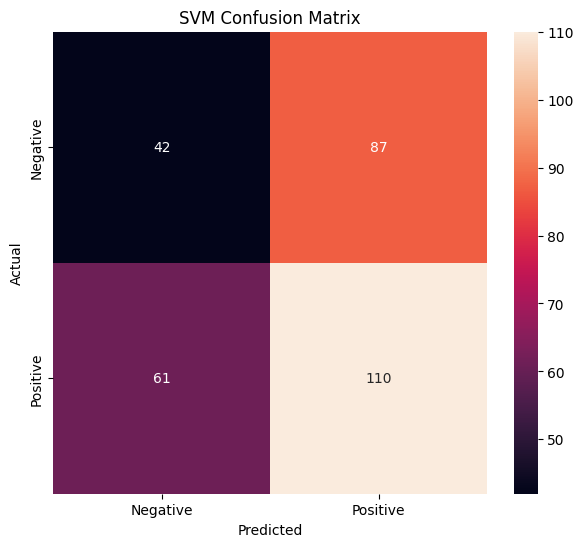

In [32]:
svm_cm = confusion_matrix(
    y_test,
    svm_predictions
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [33]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_tfidf,
    y_train
)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [34]:
rf_predictions = rf_model.predict(
    X_test_tfidf
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print(
    "Random Forest Accuracy: {:.2f}%".format(
        rf_accuracy * 100
    )
)

Random Forest Accuracy: 53.67%


In [35]:
print("Random Forest Classification Report:\n")

print(
    classification_report(
        y_test,
        rf_predictions
    )
)

Random Forest Classification Report:

              precision    recall  f1-score   support

    negative       0.42      0.19      0.26       129
    positive       0.57      0.80      0.66       171

    accuracy                           0.54       300
   macro avg       0.49      0.49      0.46       300
weighted avg       0.50      0.54      0.49       300



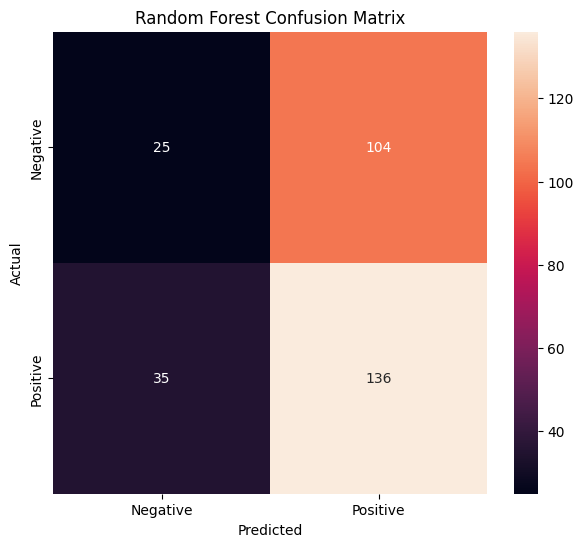

In [36]:
rf_cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [37]:
accuracy_comparison = pd.DataFrame({
    "Algorithm": [
        "SVM",
        "Random Forest"
    ],
    "Accuracy (%)": [
        svm_accuracy * 100,
        rf_accuracy * 100
    ]
})

display(accuracy_comparison)

,Algorithm,Accuracy (%)
0,SVM,50.666667
1,Random Forest,53.666667


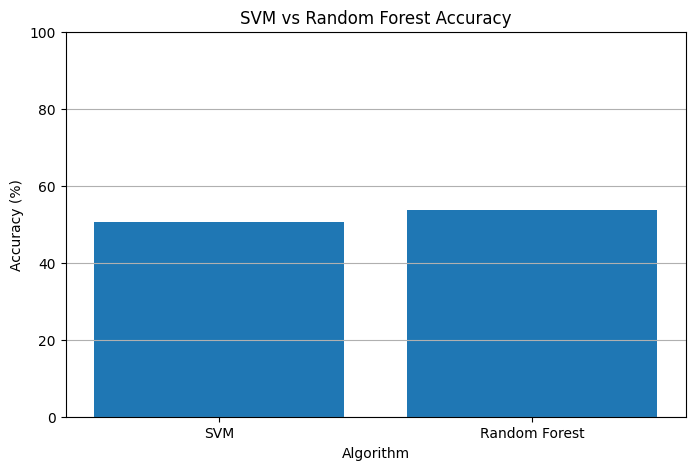

In [38]:
plt.figure(figsize=(8, 5))

plt.bar(
    accuracy_comparison["Algorithm"],
    accuracy_comparison["Accuracy (%)"]
)

plt.title("SVM vs Random Forest Accuracy")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy (%)")

plt.ylim(0, 100)
plt.grid(axis="y")

plt.show()

In [40]:
if svm_accuracy > rf_accuracy:
    best_model = "SVM"
    best_accuracy = svm_accuracy
else:
    best_model = "Random Forest"
    best_accuracy = rf_accuracy

print("Best Performing Algorithm:", best_model)
print(
    "Best Accuracy: {:.2f}%".format(
        best_accuracy * 100
    )
)

Best Performing Algorithm: Random Forest
Best Accuracy: 53.67%


In [41]:
new_text = [
    "A wonderful movie with excellent acting and an amazing story.",
    "A boring and disappointing movie with a very weak story.",
    "An exciting film with brilliant performances and great direction.",
    "A terrible and slow movie that was difficult to enjoy."
]

# Apply the same preprocessing
new_text_clean = [
    preprocess_text(text)
    for text in new_text
]

# Convert using the already trained TF-IDF
new_text_tfidf = tfidf.transform(
    new_text_clean
)

# Predictions
svm_new_predictions = svm_model.predict(
    new_text_tfidf
)

rf_new_predictions = rf_model.predict(
    new_text_tfidf
)

results = pd.DataFrame({
    "Text": new_text,
    "SVM Prediction": svm_new_predictions,
    "Random Forest Prediction": rf_new_predictions
})

display(results)

,Text,SVM Prediction,Random Forest Prediction
0,A wonderful movie with excellent acting and an...,negative,positive
1,A boring and disappointing movie with a very w...,negative,positive
2,An exciting film with brilliant performances a...,negative,positive
3,A terrible and slow movie that was difficult t...,negative,positive


In [42]:
print("=" * 60)
print("FINAL SENTIMENT ANALYSIS RESULTS")
print("=" * 60)

print("Dataset: IMDb Top 1000 Movies and TV Shows")
print("Text Feature: Overview")
print("Feature Extraction: TF-IDF")
print("Train-Test Split: 70% - 30%")
print("Preprocessing Techniques: 8")

print("\nSVM Accuracy:")
print("{:.2f}%".format(svm_accuracy * 100))

print("\nRandom Forest Accuracy:")
print("{:.2f}%".format(rf_accuracy * 100))

print("\nBest Algorithm:", best_model)
print("Best Accuracy: {:.2f}%".format(best_accuracy * 100))

print("=" * 60)

FINAL SENTIMENT ANALYSIS RESULTS
Dataset: IMDb Top 1000 Movies and TV Shows
Text Feature: Overview
Feature Extraction: TF-IDF
Train-Test Split: 70% - 30%
Preprocessing Techniques: 8

SVM Accuracy:
50.67%

Random Forest Accuracy:
53.67%

Best Algorithm: Random Forest
Best Accuracy: 53.67%


In [43]:
import joblib

joblib.dump(
    svm_model,
    "/kaggle/working/svm_sentiment_model.pkl"
)

joblib.dump(
    rf_model,
    "/kaggle/working/random_forest_sentiment_model.pkl"
)

joblib.dump(
    tfidf,
    "/kaggle/working/tfidf_vectorizer.pkl"
)

print("Models and TF-IDF vectorizer saved successfully!")

Models and TF-IDF vectorizer saved successfully!


In [ ]:
## Conclusion

In this assignment, sentiment analysis was performed using the IMDb Top 1000 Movies and TV Shows dataset. The Overview column was selected as the text data and sentiment labels were created using the median IMDb rating.

Several text preprocessing techniques were applied, including lowercase conversion, HTML tag removal, URL removal, punctuation removal, number removal, stopword removal, stemming, and whitespace normalization.

TF-IDF was used to convert the processed text into numerical features. The dataset was divided into 70% training data and 30% testing data. Two machine learning algorithms, Support Vector Machine (SVM) and Random Forest, were implemented.

The performance of both algorithms was evaluated using accuracy, classification reports, and confusion matrices. The accuracy comparison showed which algorithm performed better for this dataset.

Overall, the experiment demonstrates that TF-IDF combined with traditional machine learning algorithms can be used for text classification and sentiment analysis.

In [ ]:
## Suggestions for Accuracy Improvement

The accuracy of the sentiment analysis system can be improved in several ways:

1. Use a larger dataset containing actual movie reviews.
2. Use manually labeled positive and negative reviews instead of deriving sentiment only from IMDb ratings.
3. Apply lemmatization along with stemming.
4. Handle negation words such as "not good" more effectively.
5. Perform hyperparameter tuning for SVM and Random Forest.
6. Experiment with different TF-IDF settings and n-gram ranges.
7. Remove irrelevant or noisy text from the dataset.
8. Try other machine learning algorithms such as Logistic Regression and Naive Bayes.
9. Use deep learning approaches such as LSTM or GRU.
10. Use advanced transformer models such as BERT for better understanding of contextual meaning.